# LeetCode #202: Happy Number

https://leetcode.com/problems/happy-number/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Hash Set** | $O(\log n)$ | $O(\log n)$ |
| **Optimal: Floyd's Cycle Detection** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Hash Set
Repeatedly compute the sum of squared digits. Store each result in a set. If we reach 1, return true. If we see a repeated number, there is a cycle — return false.

### Optimal: Floyd's Cycle Detection ★
Use slow and fast pointers (like cycle detection in a linked list). Both start at `n`.
- Slow computes one step of digit-square-sum.
- Fast computes two steps.
- If there is a cycle (unhappy number), they will meet. If either reaches 1, the number is happy.

**Why this works:** The sequence of digit-square-sums either reaches 1 or enters a cycle. Floyd's algorithm detects cycles in $O(1)$ space without storing seen values.

**Constraints:**
* `1 <= n <= 2^31 - 1`

## Solutions

### C#

In [ ]:
public class Solution {
    private int GetNext(int n) {
        int sum = 0;
        while (n > 0) {
            int d = n % 10;
            sum += d * d;
            n /= 10;
        }
        return sum;
    }
    
    public bool IsHappy(int n) {
        int slow = n, fast = GetNext(n);
        while (fast != 1 && slow != fast) {
            slow = GetNext(slow);
            fast = GetNext(GetNext(fast));
        }
        return fast == 1;
    }
}

### Python

In [ ]:
class Solution:
    def isHappy(self, n: int) -> bool:
        def get_next(num):
            total = 0
            while num > 0:
                num, d = divmod(num, 10)
                total += d * d
            return total
        
        slow = n
        fast = get_next(n)
        while fast != 1 and slow != fast:
            slow = get_next(slow)
            fast = get_next(get_next(fast))
        
        return fast == 1

### Go

In [ ]:
func getNext(n int) int {
    sum := 0
    for n > 0 {
        d := n % 10
        sum += d * d
        n /= 10
    }
    return sum
}

func isHappy(n int) bool {
    slow := n
    fast := getNext(n)
    for fast != 1 && slow != fast {
        slow = getNext(slow)
        fast = getNext(getNext(fast))
    }
    return fast == 1
}

### Rust

In [ ]:
impl Solution {
    fn get_next(mut n: i32) -> i32 {
        let mut sum = 0;
        while n > 0 {
            let d = n % 10;
            sum += d * d;
            n /= 10;
        }
        sum
    }
    
    pub fn is_happy(n: i32) -> bool {
        let mut slow = n;
        let mut fast = Self::get_next(n);
        while fast != 1 && slow != fast {
            slow = Self::get_next(slow);
            fast = Self::get_next(Self::get_next(fast));
        }
        fast == 1
    }
}

## Example Scenarios

1. **Common Case:** `n = 19` → **true**. Starting from 19, compute digit-square-sums: $1^2 + 9^2 = 82 \to 68 \to 100 \to 1$. The chain reaches 1 in 4 steps, so 19 is happy. WHY tricky: The chain is 4 steps long — fast pointer reaches 1 in just 2 iterations of Floyd's loop.

2. **Slightly Complex — Unhappy Number with Long Cycle:** `n = 2` → **false**. The sequence enters an 8-element cycle: $4 \to 16 \to 37 \to 58 \to 89 \to 145 \to 42 \to 20 \to 4$. Slow and fast pointers meet at 42 after 7 steps. WHY tricky: The cycle has 8 elements, and the meeting point (42) is not the cycle entry — Floyd's guarantees meeting but not where.

3. **Edge Case — Time Factor (Maximum Digits):** `n = 1999999999` → **false**. A 10-digit number. First step: $1^2 + 9 \times 9^2 = 730$. The value collapses from 10 digits to 3 digits in one step, then enters the known cycle. WHY tricky: Even with the maximum input, digit-square-sum is bounded by $9^2 \times 10 = 810$, so the sequence converges in $O(\log n) \approx 20$ steps.

4. **Edge Case — Space Factor (O(1) vs O(log n)):** `n = 7` → **true**. Chain: $7 \to 49 \to 97 \to 130 \to 10 \to 1$. A hash-set approach stores 6 values; Floyd's uses only 2 integer variables regardless of chain length. WHY tricky: The space difference is the entire motivation for Floyd's — for large $n$, a hash set could store hundreds of intermediate values.

5. **Almost-Impossible — Boundary Value Near $2^{31}$:** `n = 2147483647` ($2^{31} - 1$, max 32-bit signed int) → **false**. Digits: 2,1,4,7,4,8,3,6,4,7. Sum of squares $= 4+1+16+49+16+64+9+36+16+49 = 260$. Then $260 \to 40 \to 16 \to 37 \to \text{cycle}$. WHY tricky: Tests max constraint boundary — the digit extraction loop must handle all 10 digits, and max sum $810 < \text{INT\_MAX}$ ensures no overflow.

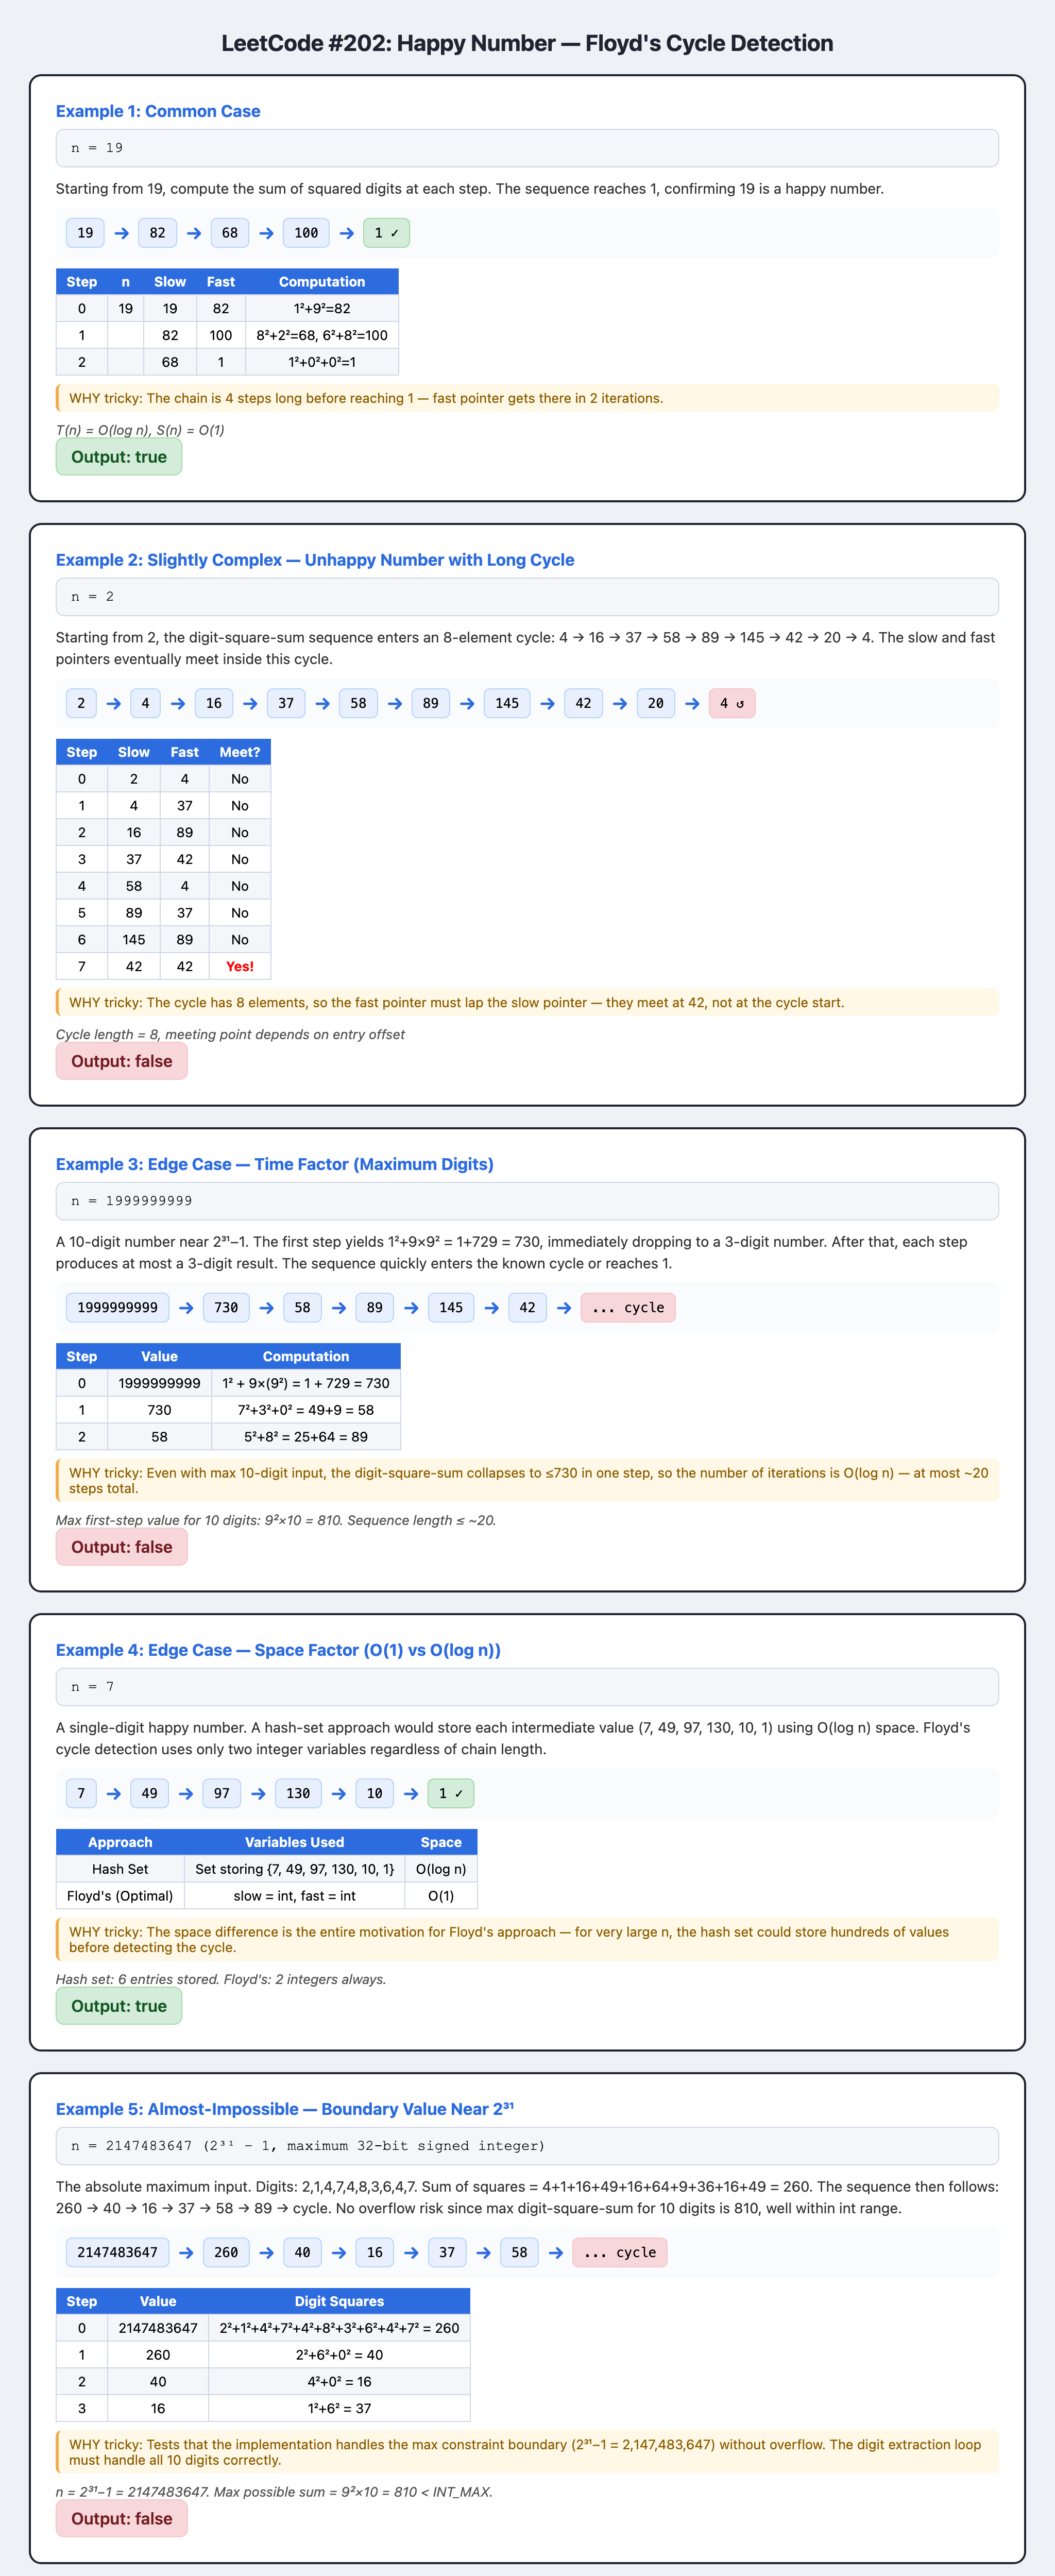